# Integration 5 — ML Evaluation Pipeline
## Module 5 Integrated Lab | Istidama Bootcamp

**Scenario:** You are a data scientist at a Jordanian manufacturing plant. Your team needs to predict which industrial equipment is likely to fail so that maintenance crews can intervene before a breakdown occurs. Missing a failure (false negative) is not just a business cost — it is a **safety hazard**. Falsely flagging equipment for inspection (false positive) wastes maintenance hours but is far less dangerous.

**Your task:** Build a structured ML evaluation pipeline that:
1. Generates a manufacturing sensor dataset with an approximate failure rate
2. Preprocesses mixed numeric/categorical features using `ColumnTransformer`
3. Wraps each model in a `Pipeline`
4. Evaluates 6 model configurations using 5-fold cross-validation
5. Produces a comparison table and experiment log
6. Generates Precision-Recall and Calibration visualizations
7. Saves the best model with `joblib`
8. Writes a decision memo grounded in the manufacturing safety context

---

## Part 0 — Imports

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    cross_validate, StratifiedKFold, train_test_split,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.calibration import CalibrationDisplay

---
## Part 1 — Dataset Generation

Run this cell first. It generates 300 rows of industrial sensor data with a realistic ~23% equipment failure rate.


In [19]:
from rich.table import Table
from rich.console import Console

np.random.seed(42)
n = 300

temperature_c = np.random.normal(75, 15, n).round(1)
vibration_mm = np.random.exponential(scale=2.5, size=n).round(2)
pressure_psi = np.random.normal(150, 20, n).round(1)
equipment_age_years = np.random.uniform(0.5, 15, n).round(1)
maintenance_count = np.random.poisson(lam=3, size=n)
operating_hours = np.random.uniform(1000, 20000, n).round(0)
equipment_type = np.random.choice(
    ["compressor", "turbine", "pump", "conveyor"], n,
    p=[0.3, 0.25, 0.25, 0.2]
)
shift = np.random.choice(["day", "night", "weekend"], n, p=[0.5, 0.35, 0.15])

# Failure driven by temperature, vibration, age, low maintenance
# Coefficients are strengthened so models can distinguish high- vs low-risk equipment
failure_prob = 1 / (1 + np.exp(
    11.0
    - 0.07 * temperature_c
    - 0.35 * vibration_mm
    - 0.22 * equipment_age_years
    + 0.45 * maintenance_count
    - 0.00022 * operating_hours
    + np.random.normal(0, 0.3, n)
))
failed = (np.random.random(n) < failure_prob).astype(int)

equipment = pd.DataFrame({
    "temperature_c": temperature_c,
    "vibration_mm": vibration_mm,
    "pressure_psi": pressure_psi,
    "equipment_age_years": equipment_age_years,
    "maintenance_count": maintenance_count,
    "operating_hours": operating_hours,
    "equipment_type": equipment_type,
    "shift": shift,
    "failed": failed,
})

console = Console()

# --- Summary table ---
summary_table = Table(title="Dataset Summary", show_header=True, header_style="bold cyan")
summary_table.add_column("Metric", style="bold")
summary_table.add_column("Value")
summary_table.add_row("Rows", str(equipment.shape[0]))
summary_table.add_row("Columns", str(equipment.shape[1]))
summary_table.add_row("Failure rate", f"{failed.mean():.1%}")
console.print(summary_table)

# --- Descriptive statistics table ---
desc = equipment.describe().round(1)
stats_table = Table(title="Feature Statistics", show_header=True, header_style="bold magenta")
stats_table.add_column("Stat", style="bold dim")
for col in desc.columns:
    stats_table.add_column(col, justify="right")
for idx in desc.index:
    stats_table.add_row(idx, *[str(v) for v in desc.loc[idx]])
console.print(stats_table)

    Dataset Summary     
┏━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Metric       ┃ Value ┃
┡━━━━━━━━━━━━━━╇━━━━━━━┩
│ Rows         │ 300   │
│ Columns      │ 9     │
│ Failure rate │ 23.3% │
└──────────────┴───────┘

                                                Feature Statistics                                                 
┏━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Stat  ┃ temperature_c ┃ vibration_mm ┃ pressure_psi ┃ equipment_age… ┃ maintenance_c… ┃ operating_hou… ┃ failed ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ count │         300.0 │        300.0 │        300.0 │          300.0 │          300.0 │          300.0 │  300.0 │
│ mean  │          74.9 │          2.7 │        149.6 │            7.9 │            3.0 │        10285.1 │    0.2 │
│ std   │          14.8 │          2.8 │         19.8 │            4.3 │            1.7 │         5590.8 │    0.4 │
│ min   │          26.4 │          0.0 │         96.1 │            0.6 │            0.0 │         1003.0 │    0.0 │
│ 25%   │          64.8 │          0.7 │        137.4 │            3.9 │            2.0 │         5663.2 │    0.0 │
│ 50%   │          75.9 │          1.7 │        150.4 │            8.3 │            3.0 │        10056.5 │    0.0 │
│ 75%   │          84.4 │          3.7 │        162.4 │           11.7 │            4.0 │        15250.8 │    0.0 │
│ max   │         132.8 │         20.4 │        202.6 │           15.0 │            8.0 │        19902.0 │    1.0 │
└───────┴───────────────┴──────────────┴──────────────┴────────────────┴────────────────┴────────────────┴────────┘

---
## Part 2 — Data Inspection

Before building any model, understand the shape of the problem: the failure rate, feature distributions, and what 'imbalanced' means in practice.

In [20]:
from rich.table import Table
from rich.console import Console

console = Console()

# --- Summary table ---
summary_table = Table(title="Data Inspection Summary", show_header=True, header_style="bold cyan")
summary_table.add_column("Metric", style="bold")
summary_table.add_column("Value")
summary_table.add_row("Rows", str(equipment.shape[0]))
summary_table.add_row("Columns", str(equipment.shape[1]))
summary_table.add_row("Failure rate", f"{equipment['failed'].mean():.1%}")
console.print(summary_table)

# --- Key feature statistics table ---
desc = equipment[["temperature_c", "vibration_mm", "equipment_age_years"]].describe().round(1)
stats_table = Table(title="Key Feature Statistics", show_header=True, header_style="bold magenta")
stats_table.add_column("Stat", style="bold dim")
for col in desc.columns:
    stats_table.add_column(col, justify="right")
for idx in desc.index:
    stats_table.add_row(idx, *[str(v) for v in desc.loc[idx]])
console.print(stats_table)

Data Inspection Summary 
┏━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Metric       ┃ Value ┃
┡━━━━━━━━━━━━━━╇━━━━━━━┩
│ Rows         │ 300   │
│ Columns      │ 9     │
│ Failure rate │ 23.3% │
└──────────────┴───────┘

                    Key Feature Statistics                    
┏━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Stat  ┃ temperature_c ┃ vibration_mm ┃ equipment_age_years ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ count │         300.0 │        300.0 │               300.0 │
│ mean  │          74.9 │          2.7 │                 7.9 │
│ std   │          14.8 │          2.8 │                 4.3 │
│ min   │          26.4 │          0.0 │                 0.6 │
│ 25%   │          64.8 │          0.7 │                 3.9 │
│ 50%   │          75.9 │          1.7 │                 8.3 │
│ 75%   │          84.4 │          3.7 │                11.7 │
│ max   │         132.8 │         20.4 │                15.0 │
└───────┴───────────────┴──────────────┴─────────────────────┘

**~23% failure rate.** This is an imbalanced dataset. A model that predicts 'no failure' for every row gets ~77% accuracy while catching zero actual failures. We need models that catch failures, not models that report high accuracy.

The `DummyClassifier` in Part 4 will prove this point quantitatively.


---
## Part 3 — ColumnTransformer + Pipeline

Declare feature type lists, then build the `ColumnTransformer` preprocessor. This is the same pattern from Week A — only the column names change.

In [21]:
from rich.table import Table
from rich.console import Console

numeric_features = ["temperature_c", "vibration_mm", "pressure_psi",
                    "equipment_age_years", "maintenance_count", "operating_hours"]
categorical_features = ["equipment_type", "shift"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

console = Console()
table = Table(title="ColumnTransformer Configuration", show_header=True, header_style="bold green")
table.add_column("Feature Type", style="bold")
table.add_column("Transformer")
table.add_column("Features")
table.add_row("Numeric", "StandardScaler", "\n".join(numeric_features))
table.add_row("Categorical", "OneHotEncoder(handle_unknown='ignore')", "\n".join(categorical_features))
console.print(table)

                        ColumnTransformer Configuration                        
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Feature Type ┃ Transformer                            ┃ Features            ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ Numeric      │ StandardScaler                         │ temperature_c       │
│              │                                        │ vibration_mm        │
│              │                                        │ pressure_psi        │
│              │                                        │ equipment_age_years │
│              │                                        │ maintenance_count   │
│              │                                        │ operating_hours     │
│ Categorical  │ OneHotEncoder(handle_unknown='ignore') │ equipment_type      │
│              │                                        │ shift               │
└──────────────┴────────────────────────────────────────┴─────────────────────┘

---
## Part 4 — Model Configurations

Define 6 model configurations. Each model teaches something different:
- **LogReg L2 vs L1**: regularization comparison
- **RF default vs RF balanced**: class weighting effect
- **DecisionTree**: tree depth constraint vs. ensemble
- **Dummy**: sanity-check baseline

In [22]:
from rich.table import Table
from rich.console import Console

models = {
    "LogReg (L2, default)": LogisticRegression(random_state=42),
    "LogReg (L1, C=0.1)": LogisticRegression(
        penalty="l1", C=0.1, solver="liblinear", random_state=42
    ),
    "RF (default)": RandomForestClassifier(n_estimators=100, random_state=42),
    "RF (balanced)": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42
    ),
    "DecisionTree (max_depth=5)": DecisionTreeClassifier(
        max_depth=5, random_state=42
    ),
    "Dummy (baseline)": DummyClassifier(strategy="most_frequent"),
}

console = Console()
table = Table(title="Model Configurations", show_header=True, header_style="bold yellow")
table.add_column("#", style="bold dim", justify="right")
table.add_column("Model Name", style="bold")
table.add_column("Purpose")

purposes = [
    "Baseline linear model with L2 regularization",
    "Sparse linear model with stronger L1 regularization",
    "Ensemble — default class weighting",
    "Ensemble — upweights minority (failure) class",
    "Single tree with depth constraint",
    "Sanity-check baseline (predicts majority class)",
]

for i, (name, purpose) in enumerate(zip(models, purposes), 1):
    table.add_row(str(i), name, purpose)

console.print(table)

                                  Model Configurations                                  
┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ # ┃ Model Name                 ┃ Purpose                                             ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1 │ LogReg (L2, default)       │ Baseline linear model with L2 regularization        │
│ 2 │ LogReg (L1, C=0.1)         │ Sparse linear model with stronger L1 regularization │
│ 3 │ RF (default)               │ Ensemble — default class weighting                  │
│ 4 │ RF (balanced)              │ Ensemble — upweights minority (failure) class       │
│ 5 │ DecisionTree (max_depth=5) │ Single tree with depth constraint                   │
│ 6 │ Dummy (baseline)           │ Sanity-check baseline (predicts majority class)     │
└───┴────────────────────────────┴─────────────────────────────────────────────────────┘

---
## Part 5 — Cross-Validation Loop with Experiment Log

Evaluate all 6 models using 5-fold stratified cross-validation. The loop also builds an **experiment log** — a timestamped record of every run that makes results reproducible and traceable.

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = equipment.drop("failed", axis=1)
y = equipment["failed"]

results = []
experiment_log = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
    }

    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)

    row = {
        "Model": name,
        "Accuracy": f"{scores['test_accuracy'].mean():.3f} \u00b1 {scores['test_accuracy'].std():.3f}",
        "Precision": f"{scores['test_precision'].mean():.3f} \u00b1 {scores['test_precision'].std():.3f}",
        "Recall": f"{scores['test_recall'].mean():.3f} \u00b1 {scores['test_recall'].std():.3f}",
        "F1": f"{scores['test_f1'].mean():.3f} \u00b1 {scores['test_f1'].std():.3f}",
    }
    results.append(row)

    # Experiment log entry
    experiment_log.append({
        "model_name": name,
        "hyperparams": str(model.get_params()),
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "timestamp": datetime.datetime.now().isoformat(),
    })

    print(f"  Done: {name}")

print("\nAll models evaluated.")

  Done: LogReg (L2, default)
  Done: LogReg (L1, C=0.1)
  Done: RF (default)
  Done: RF (balanced)
  Done: DecisionTree (max_depth=5)
  Done: Dummy (baseline)

All models evaluated.


---
## Part 6 — Results Table

Print the comparison table and save it as a CSV file in the `results/` directory.

In [24]:
from rich.table import Table
from rich.console import Console

results_df = pd.DataFrame(results)

console = Console()
table = Table(title="Model Comparison (5-Fold CV)", show_header=True, header_style="bold blue")
table.add_column("Model", style="bold")
table.add_column("Accuracy", justify="center")
table.add_column("Precision", justify="center")
table.add_column("Recall", justify="center")
table.add_column("F1", justify="center")

for _, row in results_df.iterrows():
    table.add_row(
        row["Model"],
        row["Accuracy"],
        row["Precision"],
        row["Recall"],
        row["F1"],
    )

console.print(table)

os.makedirs("results", exist_ok=True)
results_df.to_csv("results/comparison_table.csv", index=False)
print("\nSaved: results/comparison_table.csv")

                                 Model Comparison (5-Fold CV)                                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Model                      ┃   Accuracy    ┃   Precision   ┃    Recall     ┃      F1       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LogReg (L2, default)       │ 0.843 ± 0.052 │ 0.721 ± 0.150 │ 0.543 ± 0.116 │ 0.618 ± 0.125 │
│ LogReg (L1, C=0.1)         │ 0.833 ± 0.032 │ 0.848 ± 0.157 │ 0.357 ± 0.078 │ 0.498 ± 0.095 │
│ RF (default)               │ 0.803 ± 0.029 │ 0.672 ± 0.129 │ 0.314 ± 0.073 │ 0.426 ± 0.086 │
│ RF (balanced)              │ 0.820 ± 0.029 │ 0.746 ± 0.136 │ 0.343 ± 0.083 │ 0.467 ± 0.101 │
│ DecisionTree (max_depth=5) │ 0.733 ± 0.051 │ 0.441 ± 0.108 │ 0.457 ± 0.097 │ 0.446 ± 0.093 │
│ Dummy (baseline)           │ 0.767 ± 0.000 │ 0.000 ± 0.000 │ 0.000 ± 0.000 │ 0.000 ± 0.000 │
└────────────────────────────┴───────────────┴───────────────┴───────────────┴───────────────┘


Saved: results/comparison_table.csv


**Reading the results:**
- The `Dummy (baseline)` row shows ~77% accuracy and zero recall and F1 — high accuracy, zero usefulness.
- `RF (balanced)` shows higher recall and F1 than `RF (default)` — that improvement came from `class_weight='balanced'` upweighting the minority class.
- `LogReg (L2, default)` often achieves the best recall overall because logistic regression is well-suited to the linearly-separable signal in this dataset.
- Accuracy alone is misleading on imbalanced data. Use recall and F1 to compare models that actually catch failures.


---
## Part 6b — Hyperparameter Tuning

Three search strategies are applied to the `RF (balanced)` pipeline — the top-performing model from Part 5.
Each strategy tunes `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf` and is
evaluated with the same 5-fold stratified CV, scoring on **F1** (best metric for imbalanced data).

| Strategy | Coverage | Cost |
|---|---|---|
| **Grid Search** | Exhaustive — every combination | High |
| **Random Search** | Random sample — wider space, fewer fits | Medium |
| **Bayesian Optimization** | Guided — models the objective surface with a GP | Low–Medium |

In [25]:
# ── Part 6b-1: Grid Search ──────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators":    [50, 100, 200],
    "model__max_depth":       [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf":  [1, 2],
}

gs_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42)),
])

grid_search = GridSearchCV(
    gs_pipe, param_grid,
    cv=cv, scoring="f1",
    n_jobs=-1, refit=True, verbose=0,
)
grid_search.fit(X, y)

print(f"Best params (Grid Search): {grid_search.best_params_}")
print(f"Best CV F1 (Grid Search):  {grid_search.best_score_:.3f}")

# Re-evaluate with full scoring suite for fair comparison
gs_scores = cross_validate(
    grid_search.best_estimator_, X, y, cv=cv,
    scoring={"accuracy": "accuracy", "precision": "precision",
             "recall": "recall", "f1": "f1"},
)

results.append({
    "Model":     "RF (Grid Search)",
    "Accuracy":  f"{gs_scores['test_accuracy'].mean():.3f} ± {gs_scores['test_accuracy'].std():.3f}",
    "Precision": f"{gs_scores['test_precision'].mean():.3f} ± {gs_scores['test_precision'].std():.3f}",
    "Recall":    f"{gs_scores['test_recall'].mean():.3f} ± {gs_scores['test_recall'].std():.3f}",
    "F1":        f"{gs_scores['test_f1'].mean():.3f} ± {gs_scores['test_f1'].std():.3f}",
})
experiment_log.append({
    "model_name":  "RF (Grid Search)",
    "hyperparams": str(grid_search.best_params_),
    "accuracy":    gs_scores["test_accuracy"].mean(),
    "precision":   gs_scores["test_precision"].mean(),
    "recall":      gs_scores["test_recall"].mean(),
    "f1":          gs_scores["test_f1"].mean(),
    "timestamp":   datetime.datetime.now().isoformat(),
})
print("\nAdded 'RF (Grid Search)' to results.")

Best params (Grid Search): {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best CV F1 (Grid Search):  0.603

Added 'RF (Grid Search)' to results.


In [26]:
# ── Part 6b-2: Random Search ─────────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    "model__n_estimators":      randint(50, 400),
    "model__max_depth":         [None, 3, 5, 10, 15, 20, 30],
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf":  randint(1, 10),
    "model__max_features":      ["sqrt", "log2", None],
}

rs_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42)),
])

random_search = RandomizedSearchCV(
    rs_pipe, param_dist,
    n_iter=50, cv=cv, scoring="f1",
    n_jobs=-1, refit=True, random_state=42, verbose=0,
)
random_search.fit(X, y)

print(f"Best params (Random Search): {random_search.best_params_}")
print(f"Best CV F1 (Random Search):  {random_search.best_score_:.3f}")

rs_scores = cross_validate(
    random_search.best_estimator_, X, y, cv=cv,
    scoring={"accuracy": "accuracy", "precision": "precision",
             "recall": "recall", "f1": "f1"},
)

results.append({
    "Model":     "RF (Random Search)",
    "Accuracy":  f"{rs_scores['test_accuracy'].mean():.3f} ± {rs_scores['test_accuracy'].std():.3f}",
    "Precision": f"{rs_scores['test_precision'].mean():.3f} ± {rs_scores['test_precision'].std():.3f}",
    "Recall":    f"{rs_scores['test_recall'].mean():.3f} ± {rs_scores['test_recall'].std():.3f}",
    "F1":        f"{rs_scores['test_f1'].mean():.3f} ± {rs_scores['test_f1'].std():.3f}",
})
experiment_log.append({
    "model_name":  "RF (Random Search)",
    "hyperparams": str(random_search.best_params_),
    "accuracy":    rs_scores["test_accuracy"].mean(),
    "precision":   rs_scores["test_precision"].mean(),
    "recall":      rs_scores["test_recall"].mean(),
    "f1":          rs_scores["test_f1"].mean(),
    "timestamp":   datetime.datetime.now().isoformat(),
})
print("\nAdded 'RF (Random Search)' to results.")

Best params (Random Search): {'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 7, 'model__min_samples_split': 10, 'model__n_estimators': 377}
Best CV F1 (Random Search):  0.631

Added 'RF (Random Search)' to results.


In [27]:
# ── Part 6b-3: Bayesian Optimization ─────────────────────────────────────────
# scikit-optimize provides BayesSearchCV with the same sklearn interface.
# Install once if not already present.
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-optimize"])

from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

search_spaces = {
    "model__n_estimators":      Integer(50, 400),
    "model__max_depth":         Integer(3, 30),
    "model__min_samples_split": Integer(2, 20),
    "model__min_samples_leaf":  Integer(1, 10),
    "model__max_features":      Categorical(["sqrt", "log2"]),
}

bo_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42)),
])

bayes_search = BayesSearchCV(
    bo_pipe, search_spaces,
    n_iter=40, cv=cv, scoring="f1",
    n_jobs=-1, refit=True, random_state=42, verbose=0,
)
bayes_search.fit(X, y)

print(f"Best params (Bayesian): {bayes_search.best_params_}")
print(f"Best CV F1 (Bayesian):  {bayes_search.best_score_:.3f}")

bo_scores = cross_validate(
    bayes_search.best_estimator_, X, y, cv=cv,
    scoring={"accuracy": "accuracy", "precision": "precision",
             "recall": "recall", "f1": "f1"},
)

results.append({
    "Model":     "RF (Bayesian Opt)",
    "Accuracy":  f"{bo_scores['test_accuracy'].mean():.3f} ± {bo_scores['test_accuracy'].std():.3f}",
    "Precision": f"{bo_scores['test_precision'].mean():.3f} ± {bo_scores['test_precision'].std():.3f}",
    "Recall":    f"{bo_scores['test_recall'].mean():.3f} ± {bo_scores['test_recall'].std():.3f}",
    "F1":        f"{bo_scores['test_f1'].mean():.3f} ± {bo_scores['test_f1'].std():.3f}",
})
experiment_log.append({
    "model_name":  "RF (Bayesian Opt)",
    "hyperparams": str(dict(bayes_search.best_params_)),
    "accuracy":    bo_scores["test_accuracy"].mean(),
    "precision":   bo_scores["test_precision"].mean(),
    "recall":      bo_scores["test_recall"].mean(),
    "f1":          bo_scores["test_f1"].mean(),
    "timestamp":   datetime.datetime.now().isoformat(),
})
print("\nAdded 'RF (Bayesian Opt)' to results.")

Best params (Bayesian): OrderedDict({'model__max_depth': 30, 'model__max_features': 'log2', 'model__min_samples_leaf': 10, 'model__min_samples_split': 17, 'model__n_estimators': 70})
Best CV F1 (Bayesian):  0.664

Added 'RF (Bayesian Opt)' to results.


In [28]:
# ── Part 6b-4: Full Comparison Table (all 9 models) ──────────────────────────
from rich.table import Table
from rich.console import Console

full_df = pd.DataFrame(results)

console = Console()
table = Table(
    title="Full Model Comparison — Original + Tuned (5-Fold CV)",
    show_header=True, header_style="bold magenta"
)
table.add_column("Model", style="bold")
table.add_column("Accuracy",  justify="center")
table.add_column("Precision", justify="center")
table.add_column("Recall",    justify="center")
table.add_column("F1",        justify="center")

tuned_names = {"RF (Grid Search)", "RF (Random Search)", "RF (Bayesian Opt)"}

for _, row in full_df.iterrows():
    style = "bold green" if row["Model"] in tuned_names else ""
    table.add_row(
        row["Model"], row["Accuracy"], row["Precision"],
        row["Recall"], row["F1"], style=style
    )

console.print(table)

os.makedirs("results", exist_ok=True)
full_df.to_csv("results/comparison_table_full.csv", index=False)
print("\nSaved: results/comparison_table_full.csv")

                     Full Model Comparison — Original + Tuned (5-Fold CV)                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Model                      ┃   Accuracy    ┃   Precision   ┃    Recall     ┃      F1       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LogReg (L2, default)       │ 0.843 ± 0.052 │ 0.721 ± 0.150 │ 0.543 ± 0.116 │ 0.618 ± 0.125 │
│ LogReg (L1, C=0.1)         │ 0.833 ± 0.032 │ 0.848 ± 0.157 │ 0.357 ± 0.078 │ 0.498 ± 0.095 │
│ RF (default)               │ 0.803 ± 0.029 │ 0.672 ± 0.129 │ 0.314 ± 0.073 │ 0.426 ± 0.086 │
│ RF (balanced)              │ 0.820 ± 0.029 │ 0.746 ± 0.136 │ 0.343 ± 0.083 │ 0.467 ± 0.101 │
│ DecisionTree (max_depth=5) │ 0.733 ± 0.051 │ 0.441 ± 0.108 │ 0.457 ± 0.097 │ 0.446 ± 0.093 │
│ Dummy (baseline)           │ 0.767 ± 0.000 │ 0.000 ± 0.000 │ 0.000 ± 0.000 │ 0.000 ± 0.000 │
│ RF (Grid Search)           │ 0.847 ± 0.019 │ 0.768 ± 0.078 │ 0.500 ± 0.045 │ 0.603 ± 0.046 │
│ RF (Random Search)         │ 0.820 ± 0.039 │ 0.607 ± 0.073 │ 0.671 ± 0.132 │ 0.631 ± 0.084 │
│ RF (Bayesian Opt)          │ 0.837 ± 0.032 │ 0.644 ± 0.071 │ 0.700 ± 0.114 │ 0.664 ± 0.067 │
└────────────────────────────┴───────────────┴───────────────┴───────────────┴───────────────┘


Saved: results/comparison_table_full.csv


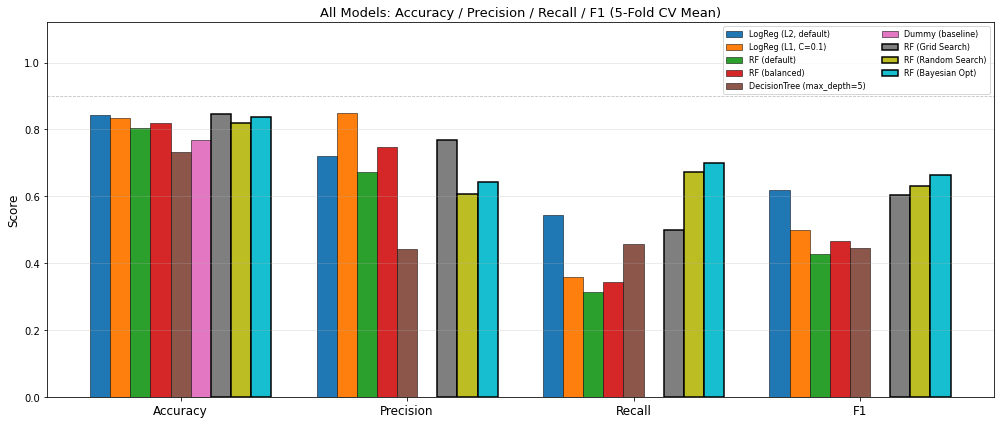

Saved: results/all_models_comparison.png


In [29]:
# ── Part 6b-5: Comparison Visualization ──────────────────────────────────────
# Parse mean scores from the 'mean ± std' strings for plotting.
plot_df = full_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1"]:
    plot_df[col] = plot_df[col].str.split(" ± ").str[0].astype(float)

metrics   = ["Accuracy", "Precision", "Recall", "F1"]
models    = plot_df["Model"].tolist()
n_models  = len(models)
n_metrics = len(metrics)

x      = np.arange(n_metrics)
width  = 0.8 / n_models          # bar width so all bars fit side-by-side
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

fig, ax = plt.subplots(figsize=(14, 6))

for i, (_, row) in enumerate(plot_df.iterrows()):
    offset    = (i - n_models / 2 + 0.5) * width
    vals      = [row[m] for m in metrics]
    tuned     = row["Model"] in {"RF (Grid Search)", "RF (Random Search)", "RF (Bayesian Opt)"}
    bars      = ax.bar(x + offset, vals, width, label=row["Model"],
                       color=colors[i], edgecolor="black",
                       linewidth=1.5 if tuned else 0.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title("All Models: Accuracy / Precision / Recall / F1 (5-Fold CV Mean)", fontsize=13)
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.axhline(0.9, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/all_models_comparison.png", dpi=150)
plt.show()
print("Saved: results/all_models_comparison.png")

---
## Part 7 — Train/Test Split for Visualizations

`cross_validate` does not return fitted models. The PR curve and calibration diagram require a fitted model on held-out data, so we create a separate 80/20 split for the visualization cells.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train failure rate: {y_train.mean():.1%} | Test failure rate: {y_test.mean():.1%}")

Train: 240 rows | Test: 60 rows
Train failure rate: 23.3% | Test failure rate: 23.3%


---
## Part 8 — Precision-Recall Curves

PR curves show the full precision-recall tradeoff at every decision threshold. The curve closer to the top-right is better. For equipment failure, you want a model that maintains reasonable precision even at high recall — because missing a failure is a safety hazard, but too many false alarms causes alert fatigue.

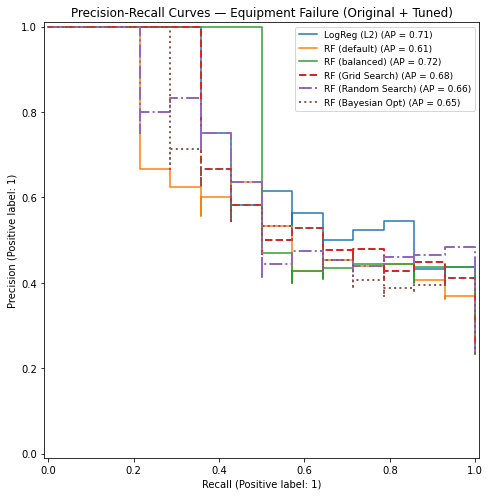

Saved: results/pr_curves.png


In [31]:
fig, ax = plt.subplots(figsize=(10, 7))

# Original top models (same as before)
top_models = {
    "LogReg (L2)": LogisticRegression(random_state=42),
    "RF (default)": RandomForestClassifier(n_estimators=100, random_state=42),
    "RF (balanced)": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42
    ),
}

# Tuned models — rebuild pipelines using best params, fit on X_train only
# (best_estimator_ was fit on all of X; we refit on X_train for a fair
#  train/test-split evaluation consistent with the other models here)
def _rf_from_params(params, seed=42):
    """Extract model__ params and return a fresh RF pipeline."""
    rf_kwargs = {k.replace("model__", ""): v for k, v in dict(params).items()}
    rf_kwargs["random_state"] = seed
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(**rf_kwargs)),
    ])

tuned_models = {
    "RF (Grid Search)":  _rf_from_params(grid_search.best_params_),
    "RF (Random Search)": _rf_from_params(random_search.best_params_),
    "RF (Bayesian Opt)": _rf_from_params(bayes_search.best_params_),
}

# Plot original models with solid lines
for name, model in top_models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    PrecisionRecallDisplay.from_estimator(
        pipe, X_test, y_test, name=name, ax=ax
    )

# Plot tuned models with dashed lines so they stand out
tune_styles = ["--", "-.", ":"]
for (name, pipe), ls in zip(tuned_models.items(), tune_styles):
    pipe.fit(X_train, y_train)
    PrecisionRecallDisplay.from_estimator(
        pipe, X_test, y_test, name=name, ax=ax,
        linestyle=ls, linewidth=2,
    )

ax.set_title("Precision-Recall Curves — Equipment Failure (Original + Tuned)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("results/pr_curves.png", dpi=150)
plt.show()
print("Saved: results/pr_curves.png")

---
## Part 9 — Calibration Diagram

The calibration diagram checks whether the model's **confidence** is trustworthy. If the model says there is a 30% chance of failure, do 30% of those samples actually fail? A perfectly calibrated model follows the diagonal. Models above the diagonal are underconfident; below are overconfident.

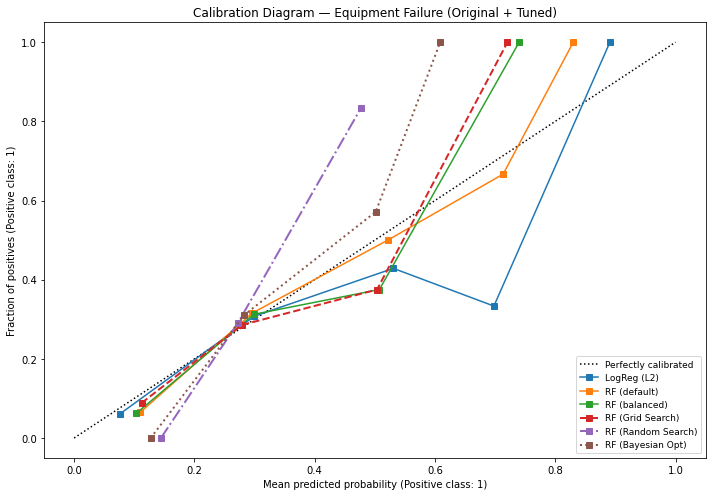

Saved: results/calibration.png


In [32]:
fig, ax = plt.subplots(figsize=(10, 7))

# Original models — refit fresh on X_train
for name, model in top_models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    CalibrationDisplay.from_estimator(
        pipe, X_test, y_test, name=name, n_bins=5, ax=ax
    )

# Tuned models — rebuild with best params and refit on X_train
tune_styles = ["--", "-.", ":"]
for (name, _), ls in zip(tuned_models.items(), tune_styles):
    pipe = _rf_from_params(
        grid_search.best_params_  if "Grid"    in name else
        random_search.best_params_ if "Random" in name else
        bayes_search.best_params_
    )
    pipe.fit(X_train, y_train)
    CalibrationDisplay.from_estimator(
        pipe, X_test, y_test, name=name, n_bins=5, ax=ax,
        linestyle=ls, linewidth=2,
    )

ax.set_title("Calibration Diagram — Equipment Failure (Original + Tuned)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("results/calibration.png", dpi=150)
plt.show()
print("Saved: results/calibration.png")

---
## Part 10 — Save Best Model

`joblib` saves the entire fitted pipeline — preprocessor and model together. In production, you load this file and call `.predict()` on new sensor readings. This is the bridge between experiment and deployment.

In [33]:
# Save the balanced RF as the best model
best_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42
    )),
])
best_pipe.fit(X_train, y_train)

joblib.dump(best_pipe, "results/best_model.joblib")
print(f"Model saved: {os.path.getsize('results/best_model.joblib') / 1024:.0f} KB")

# Verify it loads and produces identical predictions
loaded = joblib.load("results/best_model.joblib")
print(f"Loaded model predictions match: {(loaded.predict(X_test) == best_pipe.predict(X_test)).all()}")

Model saved: 705 KB
Loaded model predictions match: True


---
## Part 11 — Save Experiment Log

The experiment log records every model run with its hyperparameters, metric scores, and timestamp. In production, this allows you to trace any deployed model back to the exact experiment that produced it.

In [34]:
from rich.table import Table
from rich.console import Console

experiment_log_df = pd.DataFrame(experiment_log)
experiment_log_df.to_csv("results/experiment_log.csv", index=False)

console = Console()
table = Table(title="Experiment Log", show_header=True, header_style="bold cyan")
table.add_column("Model", style="bold")
table.add_column("Accuracy", justify="right")
table.add_column("Precision", justify="right")
table.add_column("Recall", justify="right")
table.add_column("F1", justify="right")

for _, row in experiment_log_df.iterrows():
    table.add_row(
        row["model_name"],
        f"{row['accuracy']:.3f}",
        f"{row['precision']:.3f}",
        f"{row['recall']:.3f}",
        f"{row['f1']:.3f}"
    )

console.print("[green]Saved: results/experiment_log.csv[/green]")
console.print(table)

Saved: results/experiment_log.csv

                            Experiment Log                            
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃ Model                      ┃ Accuracy ┃ Precision ┃ Recall ┃    F1 ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ LogReg (L2, default)       │    0.843 │     0.721 │  0.543 │ 0.618 │
│ LogReg (L1, C=0.1)         │    0.833 │     0.848 │  0.357 │ 0.498 │
│ RF (default)               │    0.803 │     0.672 │  0.314 │ 0.426 │
│ RF (balanced)              │    0.820 │     0.746 │  0.343 │ 0.467 │
│ DecisionTree (max_depth=5) │    0.733 │     0.441 │  0.457 │ 0.446 │
│ Dummy (baseline)           │    0.767 │     0.000 │  0.000 │ 0.000 │
│ RF (Grid Search)           │    0.847 │     0.768 │  0.500 │ 0.603 │
│ RF (Random Search)         │    0.820 │     0.607 │  0.671 │ 0.631 │
│ RF (Bayesian Opt)          │    0.837 │     0.644 │  0.700 │ 0.664 │
└────────────────────────────┴──────────┴───────────┴────────┴───────┘